In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[5]:


#!/usr/bin/env python
# coding: utf-8
"""
B-Pillar CGNN v2 - Improved Demo Code
Synod design deliberation 결과 반영:
  1. Per-block FiLM Generators (4개 독립 generator)
  2. compute_smoothness_loss 수정: 절대 엣지 길이 → 상대 변화량 기반
  3. 그래디언트 클리핑 추가 (IFT 역전파 안정성)
  4. Section continuity loss 추가 (3D 형상 연속성)
  5. Monotonicity loss 추가 (Inner < Reinf < Outer Y좌표 순서 강제)
  6. 코드 일관성: in_channels=7 명시적 기본값, base_coords 전달 구조화
"""

import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


## ─────────────────────────────────────────────────────────────
## Full Plastic Moment (Differentiable via IFT)
## ─────────────────────────────────────────────────────────────

class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Bisection으로 인장력=압축력 평형점(y_pna) 탐색
    Backward: IFT로 ∂y_pna/∂coords 계산 → chain-rule로 ∂Mp/∂coords 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        with torch.no_grad():
            y = coords[:, 1]
            t_flat = t.squeeze(-1)
            fy_flat = fy.squeeze(-1)

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                F_tens = torch.sum(t_flat * fy_flat * torch.clamp(y - y_mid, min=0.0))
                F_comp = torch.sum(t_flat * fy_flat * torch.clamp(y_mid - y, min=0.0))
                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)

        d = torch.abs(coords[:, 1] - y_pna)
        area = t_flat
        mp_pred = torch.sum(area * fy_flat * d)

        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        s = torch.sign(y - y_pna)

        dg_dy_pna = -torch.sum(t_flat * fy_flat)
        dg_dy = s * t_flat * fy_flat
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)

        direct = t_flat * fy_flat * s
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy
        dMp_dy = direct + indirect

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)

In [ ]:
## ─────────────────────────────────────────────────────────────
## Model Architecture (v3)
## ─────────────────────────────────────────────────────────────

class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]

    Fix 1: target_mp 정규화 (1,500,000 → 1.5) — 미정규화 시 Linear 가중치에 의해
            gamma/beta ≈ ±3.6M 발생 → h = gamma*h + beta로 hidden state 완전 파괴
    Fix 2: 마지막 레이어 zero-init → 초기 delta_gamma≈0, beta≈0 → identity mapping 보장
    Fix 3: (1 + delta_gamma) 공식 → 초기 gamma=1, 안정적 학습 시작
    """
    MP_SCALE = 1e6  # 1,500,000 → 1.5, 1,000,000 → 1.0

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        ## 마지막 레이어 zero-init: 초기 delta_gamma=0, beta=0 → h = (1+0)*h + 0 = h
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        ## 정규화: 1,500,000 → 1.5, 1,000,000 → 1.0
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        ## Identity mapping 유도: gamma = 1 + δγ (초기 δγ≈0 → gamma≈1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)              ## Normalize FIRST (AdaIN pattern)
        h = gamma * h + beta          ## FiLM AFTER norm → conditioning preserved
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v3)

    v3 개선사항:
    - in_channels=8: fix_x, fix_y 분리 (이전 is_fixed 단일 → 축별 독립 고정)
    - fix_x_mask, fix_y_mask: X축/Y축 변위 독립 hard constraint
    - join_pairs: 접합 노드 쌍을 hard projection으로 동시 이동 보장

    입력 노드 특징 (in_channels=8):
        [x, y, fix_x, fix_y, part_id, section_id, t, fy]
        fix_x=1: X좌표 고정, fix_y=1: Y좌표 고정 (독립 설정 가능)
    엣지 특징 (edge_dim=4):
        [길이, 각도, part_id, edge_type]
    조건부 입력:
        target_mp [N, 1] (노드별 목표 전소성 모멘트)
    join_pairs [P, 2]:
        hard joining 쌍 인덱스 — 두 노드의 좌표를 평균으로 hard projection
    """

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        ## 1. Node Encoder
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        ## 2. Per-block FiLM Generators
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])

        ## 3. GATv2 Message-Passing Blocks
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        ## 4. Coordinate Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        """
        x             : [N, in_channels]  노드 특징
        edge_index    : [2, E]
        edge_attr     : [E, edge_dim]
        target_mp     : [N, 1]   노드별 목표 전소성 모멘트
        fix_x_mask    : [N, 1]   X축 고정 Boolean 마스크
        fix_y_mask    : [N, 1]   Y축 고정 Boolean 마스크
        join_pairs    : [P, 2]   hard joining 노드 쌍 인덱스 (없으면 None)
        """
        h = self.node_encoder(x)

        ## Per-block FiLM conditioning
        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)

        ## ── Hard constraint: X축/Y축 독립 고정 ──
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)

        new_coords = x[:, :2] + delta_coords

        ## ── Hard joining: 접합 노드 쌍을 좌표 평균으로 projection ──
        ## 두 노드 u, v의 변형 후 좌표를 (coord_u + coord_v) / 2로 강제
        ## gradient는 두 노드에 균등 분배됨 (autograd 정상 동작)
        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5  # [P, 2]
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        return new_coords, delta_coords


## ─────────────────────────────────────────────────────────────
## Loss Functions (v2, unchanged)
## ─────────────────────────────────────────────────────────────

def compute_smoothness_loss(new_coords, base_coords, edge_index, edge_attr):
    """v3: 구조 엣지(edge_type=0) 기준 상대 길이 변화량 최소화"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    ## 구조 엣지만 사용 + 양방향 중복 제거
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]
    new_diff = new_coords[src] - new_coords[dst]
    base_diff = base_coords[src] - base_coords[dst]
    new_len = torch.norm(new_diff, dim=1)
    base_len = torch.norm(base_diff, dim=1)
    rel_change = (new_len - base_len) / torch.clamp(base_len, min=1.0)
    return torch.mean(rel_change ** 2)


def compute_collision_loss(new_coords, part_ids, section_ids, margin=0.5):
    """층별 다중 파트 간섭 방지 (Y좌표 기반)"""
    total_collision_loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)

    for lvl in unique_sections:
        lvl_mask = (section_ids == lvl)
        y_lvl = new_coords[lvl_mask, 1]
        p_lvl = part_ids[lvl_mask]

        mask_1 = (p_lvl == 0)  # Outer
        mask_2 = (p_lvl == 1)  # Reinf
        mask_3 = (p_lvl == 2)  # Inner

        if mask_2.any() and mask_3.any():
            gap_3_2 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_2].min() + margin, min=0.0)
            total_collision_loss += gap_3_2 ** 2
            gap_2_1 = torch.clamp(y_lvl[mask_2].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_2_1 ** 2
        elif mask_3.any() and mask_1.any():
            gap_3_1 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_3_1 ** 2

    return total_collision_loss


def compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids):
    """인접 섹션 간 같은 파트의 평균 변위 차이 최소화"""
    loss = torch.tensor(0.0, device=new_coords.device)
    delta = new_coords - base_coords

    unique_sections = torch.unique(section_ids)
    unique_parts = torch.unique(part_ids)

    for i in range(len(unique_sections) - 1):
        sec_a = unique_sections[i]
        sec_b = unique_sections[i + 1]

        for part in unique_parts:
            mask_a = (section_ids == sec_a) & (part_ids == part)
            mask_b = (section_ids == sec_b) & (part_ids == part)

            if mask_a.any() and mask_b.any():
                mean_delta_a = delta[mask_a].mean(dim=0)
                mean_delta_b = delta[mask_b].mean(dim=0)
                loss += torch.sum((mean_delta_b - mean_delta_a) ** 2)

    return loss


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area=None):
    """총 질량(또는 목표 질량 오차)을 계산

    - 기본 동작: 엣지 길이 * 두께 합산 → 면적(질량)
    - ``target_area``가 주어지면 상대 오차 제곱을 반환하여
      손실로 사용할 수 있음.
    """

    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    ## 구조 엣지(edge_type=0)만 질량 근사에 사용 + 양방향 중복 제거
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)
    return area, (area - target_area)**2 if target_area is not None else area


In [ ]:
## ─────────────────────────────────────────────────────────────
## Training Step (v3)
## ─────────────────────────────────────────────────────────────

def train_step(model, data, optimizer, target_mps,
               target_area=None,
               w_phys=10000000.0, w_smooth=0.01, w_mass=0.0001,
               w_collision=10.0, w_fix=100.0,
               w_monotone=10.0, w_continuity=1.0,
               max_grad_norm=1.0):
    """
    v3 변경사항:
    - 노드 피처 8열: [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    - fix_x_mask, fix_y_mask 분리 추출
    - join_pairs 전달 (hard joining 적용)
    - 열 인덱스 전체 업데이트
    - target_area: 전체(또는 섹션별) 목표 질량을 지정하면
      compute_mass_loss에서 오차 기반 손실을 계산함
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x                          ## [N, 8]
    edge_index = data.edge_index                 ## [2, E]
    edge_attr  = data.edge_attr                  ## [E, 4]
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = data.x[:, :2].detach()         ## [N, 2] 초기 좌표

    ## ── 노드 피처 추출 (v3: 8열 기준) ──
    fix_x_mask  = x[:, 2].bool().unsqueeze(1)    ## X축 고정 마스크
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)    ## Y축 고정 마스크
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    t           = x[:, 6].unsqueeze(1)
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    ## ── 노드별 목표 Mp 텐서 생성 ──
    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    ## ── GNN Forward Pass ──
    new_coords, delta_coords = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    ## ── 층별 물리 손실 (L_phys) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t[section_mask]
        fy_section = fy[section_mask]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, None)
        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = ((pred_mp_section - target_mp_section) / target_mp_section) ** 2
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = l_phys_total / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    ## ── 다목적 손실 계산 ──
    l_smooth     = compute_smoothness_loss(new_coords, base_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss(new_coords, part_ids, section_ids)
    l_continuity = compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids)

    ## ── 고정점 손실: fix_x 또는 fix_y가 있는 노드의 delta 크기 ──
    any_fixed = (fix_x_mask | fix_y_mask).squeeze()
    if any_fixed.any():
        l_fix = torch.sum(torch.norm(delta_coords[any_fixed], dim=1))
    else:
        l_fix = torch.tensor(0.0, device=x.device)

    ## ── Total Loss ──
    loss = (w_phys       * l_phys_total
          + w_smooth     * l_smooth
          + w_mass       * l_mass
          + w_collision  * l_collision
          + w_fix        * l_fix
          + w_continuity * l_continuity)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
    optimizer.step()

    return {
        "loss":          loss.item(),
        "pred_mp":       pred_mp_sections,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "l_collision":   l_collision.item(),
        "l_fix":         l_fix.item() if isinstance(l_fix, torch.Tensor) else l_fix,
        "l_continuity":  l_continuity.item(),
        "new_coords":    new_coords.detach(),
    }


Nodes: torch.Size([80, 8]) | Edges: torch.Size([2, 244]) | Edge Features: torch.Size([244, 4]) | Join Pairs: torch.Size([0])


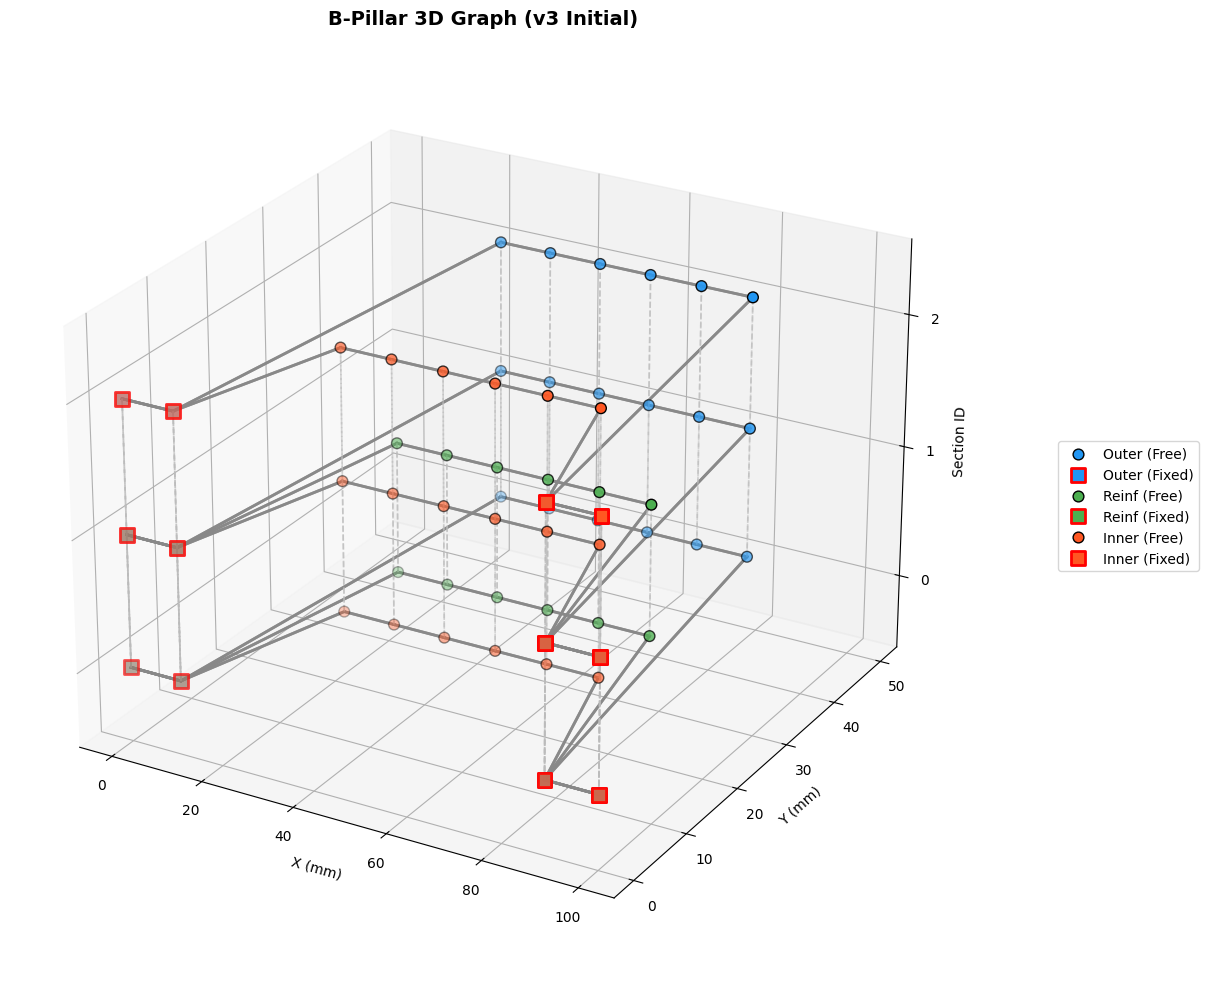

In [ ]:
## ─────────────────────────────────────────────────────────────
## Data Construction (v3: 8-feature nodes + join_pairs)
## ─────────────────────────────────────────────────────────────
"""
B-Pillar 3x3 구조:
  section 0 (1층): part 0(Outer), 1(Reinf), 2(Inner)
  section 1 (2층): part 0(Outer), 1(Reinf), 2(Inner)
  section 2 (3층): part 0(Outer), 2(Inner)  ← Reinf 없음

노드 피처 (8열):
  [x, y, fix_x, fix_y, part_id, section_id, t, fy]
  fix_x=1: X축 고정, fix_y=1: Y축 고정 (독립 설정)

경계조건:
  - is_fixed(xy 동시): 양 끝 플랜지 노드 i=0,1,8,9 → fix_x=fix_y=1
  - section 0,2의 Outer 중간 노드 i=3,6 → fix_x=fix_y=1

join_pairs:
  - 플랜지 위치(i=0,9)에서 파트 간 hard joining
  - 실제 용접/볼트 접합 표현 (동시이동 hard 보장)
"""

num_nodes_total = 80
num_nodes = 10
x = torch.zeros((num_nodes_total, 8), dtype=torch.float32)  ## v3: 8열

node_registry = {}
current_idx = 0

for section in [0, 1, 2]:
    parts_in_section = [0, 1, 2] if section in [0, 1] else [0, 2]

    for part in parts_in_section:
        for i in range(num_nodes):
            x_coord = i * (100.0 / 9.0)
            if i in [0, 1, 8, 9]:
                y_coord = 0.0
            else:
                y_coord = 20.0 if part == 2 else 30.0 if part == 1 else 50.0

            fix_x = 1.0 if (i in [0, 1, 8, 9]) else 0.0
            fix_y = 1.0 if (i in [0, 1, 8, 9]) else 0.0

            t_val  = 1.5 if part != 1 else 2.0
            fy_val = 1500.0 if part != 2 else 1200.0

            ## [x, y, fix_x, fix_y, part_id, section_id, t, fy]
            x[current_idx] = torch.tensor([x_coord, y_coord, fix_x, fix_y,
                                            float(part), float(section), t_val, fy_val])
            node_registry[(section, part, i)] = current_idx
            current_idx += 1

## ── Edge Construction ──
src_list, dst_list = [], []
edge_attr_list = []

def add_edge(u, v, part_id, edge_type):
    src_list.extend([u, v])
    dst_list.extend([v, u])
    dx = x[v, 0] - x[u, 0]
    dy = x[v, 1] - x[u, 1]
    length = math.sqrt(dx**2 + dy**2)
    angle = math.atan2(dy, dx)
    edge_attr_list.extend([[length, angle, part_id, edge_type],
                            [length, -angle, part_id, edge_type]])

# Intra-section (횡방향)
for section in [0, 1, 2]:
    parts = [0, 1, 2] if section in [0, 1] else [0, 2]
    for part in parts:
        for i in range(num_nodes - 1):
            u = node_registry[(section, part, i)]
            v = node_registry[(section, part, i+1)]
            add_edge(u, v, part_id=part, edge_type=0.0)

# Inter-section (종방향: 3D 연속성)
for section in [0, 1]:
    next_section = section + 1
    parts = [0, 2] if next_section == 2 else [0, 1, 2]
    for part in parts:
        for i in range(num_nodes):
            u = node_registry[(section, part, i)]
            v = node_registry[(next_section, part, i)]
            add_edge(u, v, part_id=part, edge_type=1.0)

# Flange binding (파트 끝점 결합)
for section in [0, 1, 2]:
    for i in [0, 9]:
        u0 = node_registry[(section, 0, i)]
        u2 = node_registry[(section, 2, i)]
        if section in [0, 1]:
            u1 = node_registry[(section, 1, i)]
            add_edge(u0, u1, part_id=0.0, edge_type=2.0)
            add_edge(u1, u2, part_id=0.0, edge_type=2.0)
        add_edge(u0, u2, part_id=0.0, edge_type=2.0)

# Part binding (메시지 패싱 엣지 전체 연결, edge_type=2; hard joining은 끝단만)
join_pairs_list = []
# for section in [0, 1, 2]:
#     for i in range(num_nodes):
#         u0 = node_registry[(section, 0, i)]
#         u2 = node_registry[(section, 2, i)]
#         if section in [0, 1]:
#             u1 = node_registry[(section, 1, i)]

#         # hard joining: 실제 접합 위치(끝단)만 강제
#         if i in [3, 4, 5, 6]:
#             # join_pairs_list.append([u0, u2])
#             if section in [0, 1]:
#                 join_pairs_list.append([u0, u1])
#                 # join_pairs_list.append([u1, u2])

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
join_pairs = torch.tensor(join_pairs_list, dtype=torch.long)

print(f"Nodes: {x.shape} | Edges: {edge_index.shape} | "
      f"Edge Features: {edge_attr.shape} | Join Pairs: {join_pairs.shape}")


## ─────────────────────────────────────────────────────────────
## 3D Visualization (v3: 열 인덱스 업데이트)
## ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x_np  = x.cpu().numpy()
ei_np = edge_index.cpu().numpy()
ea_np = edge_attr.cpu().numpy()

color_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}

for i in range(ei_np.shape[1]):
    u = ei_np[0, i]
    v = ei_np[1, i]
    e_type = ea_np[i, 3]
    xs = [x_np[u, 0], x_np[v, 0]]
    ys = [x_np[u, 1], x_np[v, 1]]
    zs = [x_np[u, 5], x_np[v, 5]]         ## v3: section_id → col 5
    if e_type == 0.0:
        ax.plot(xs, ys, zs, color='#888888', linestyle='-',  linewidth=2.0, alpha=0.9)
    elif e_type == 1.0:
        ax.plot(xs, ys, zs, color='#BBBBBB', linestyle='--', linewidth=1.2, alpha=0.6)
    elif e_type == 2.0:
        ax.plot(xs, ys, zs, color='red',     linestyle=':',  linewidth=3.0, alpha=0.9)

for part_id in [0, 1, 2]:
    ## v3: part_id → col 4, fix_x → col 2, fix_y → col 3
    is_any_fixed = (x_np[:, 2] > 0) | (x_np[:, 3] > 0)
    mask       = (x_np[:, 4] == part_id) & ~is_any_fixed
    mask_fixed = (x_np[:, 4] == part_id) &  is_any_fixed
    part_name = {0: 'Outer', 1: 'Reinf', 2: 'Inner'}[part_id]
    ax.scatter(x_np[mask, 0], x_np[mask, 1], x_np[mask, 5],
               c=color_map[part_id], marker='o', s=60, edgecolors='k', label=f'{part_name} (Free)')
    if mask_fixed.any():
        ax.scatter(x_np[mask_fixed, 0], x_np[mask_fixed, 1], x_np[mask_fixed, 5],
                   c=color_map[part_id], marker='s', s=100, edgecolors='red', linewidths=2.0,
                   label=f'{part_name} (Fixed)')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Section ID')
ax.set_title('B-Pillar 3D Graph (v3 Initial)', fontsize=14, fontweight='bold')
ax.set_zticks([0, 1, 2])
ax.set_zlim(-0.5, 2.5)
ax.view_init(elev=25, azim=-60)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
plt.show()



Initial Mp:
  Section 2 (3층, Outer+Inner only): 756000 N·mm
  Section 1 (2층, all parts):        1151234 N·mm
  Section 0 (1층, all parts):        1151234 N·mm
CGDN v3 Training Log
Model params: 213,058
Join pairs  : 0 pairs
Epoch 000 | Loss: 820828.8750 | Mp: [1159266.75 1159253.    759697.25] / [1500000, 1500000, 1000000] | Phys: 0.0536  Smth: 0.0000  area: 1939.7538 / 2200.0000  Mass: 67728.0938  Coll: 3171.5720  Mono: 4532.9517  Cont: 0.0000
Epoch 010 | Loss: 99280.8594 | Mp: [1579337.5  1577642.5   928963.75] / [1500000, 1500000, 1000000] | Phys: 0.0035  Smth: 0.0285  area: 2239.2368 / 2200.0000  Mass: 1539.5277  Coll: 6743.9370  Mono: 9426.5557  Cont: 0.8149
Epoch 020 | Loss: 90314.2812 | Mp: [1466957.     1465889.5     878210.9375] / [1500000, 1500000, 1000000] | Phys: 0.0053  Smth: 0.0157  area: 2161.2224 / 2200.0000  Mass: 1503.7013  Coll: 5675.9966  Mono: 7959.5264  Cont: 0.1975
Epoch 030 | Loss: 75815.1953 | Mp: [1511823.75   1511008.5     905421.5625] / [1500000, 1500000, 10

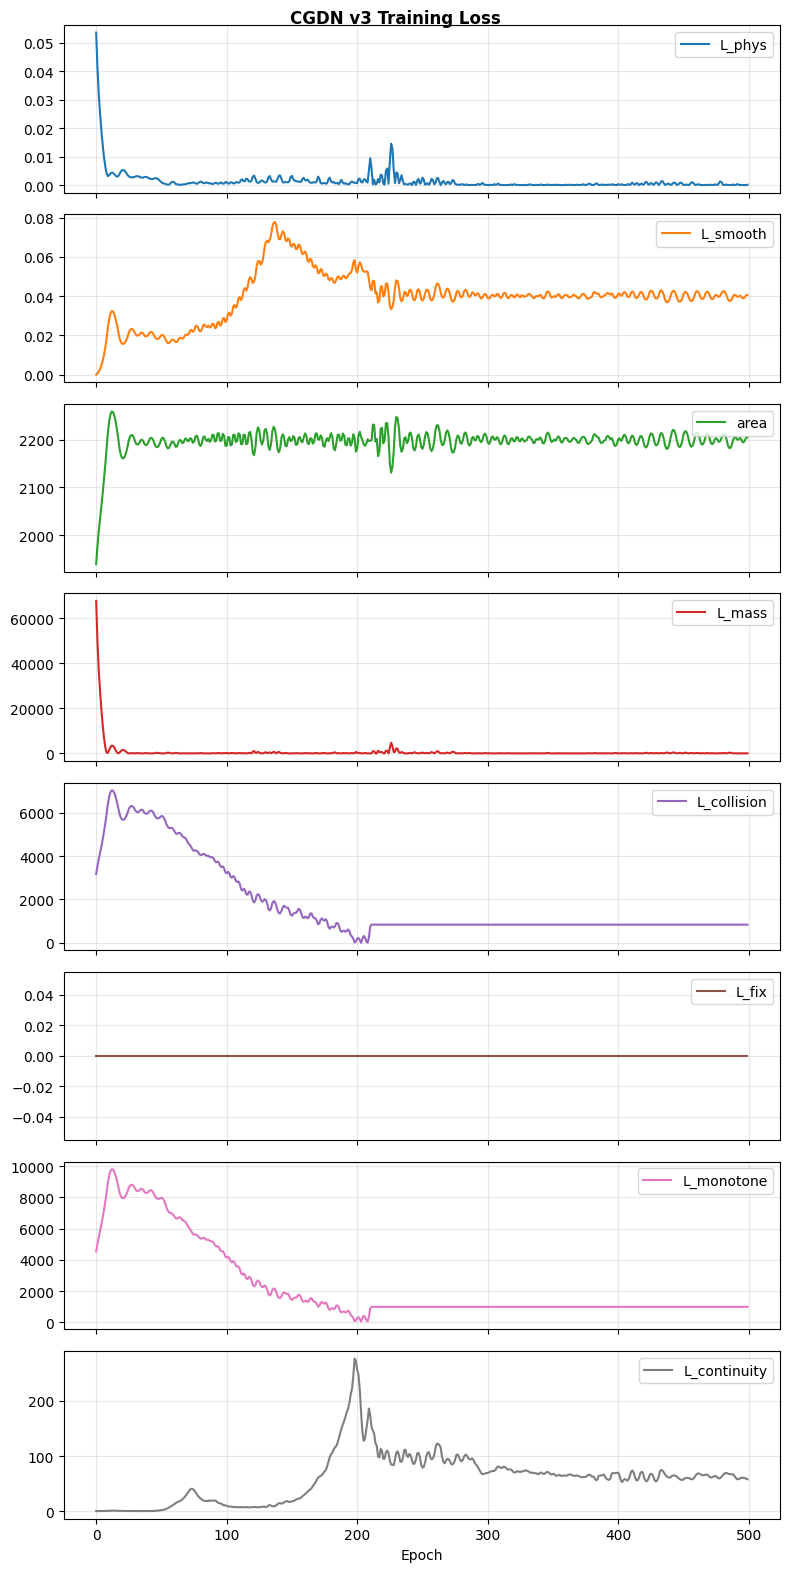

In [ ]:
## ─────────────────────────────────────────────────────────────
## Initial Mp Check (v3: 열 인덱스 업데이트 — t=col6, fy=col7)
## 노드 범위: section0=0:30, section1=30:60, section2=60:80
## ─────────────────────────────────────────────────────────────

print(f"\nInitial Mp:")
print(f"  Section 2 (3층, Outer+Inner only): "
      f"{calculate_mpl(x[60:, :2], x[60:, 6:7], x[60:, 7:8], None):.0f} N·mm")
print(f"  Section 1 (2층, all parts):        "
      f"{calculate_mpl(x[30:60, :2], x[30:60, 6:7], x[30:60, 7:8], None):.0f} N·mm")
print(f"  Section 0 (1층, all parts):        "
      f"{calculate_mpl(x[:30, :2], x[:30, 6:7], x[:30, 7:8], None):.0f} N·mm")


## ─────────────────────────────────────────────────────────────
## Training (v3)
## ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    in_channels      = 8       ## v3: [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    hidden_channels  = 128
    num_layers       = 4
    heads            = 4
    edge_feature_dim = 4
    learning_rate    = 1e-3
    weight_decay     = 1e-4
    max_epochs       = 500
    target_mps       = {0: 1500000, 1: 1500000, 2: 1000000}
    target_area      = 0
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = CGDN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        heads=heads,
        edge_dim=edge_feature_dim,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                join_pairs=join_pairs).to(device)

    print("=" * 70)
    print("CGDN v3 Training Log")
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Join pairs  : {join_pairs.shape[0]} pairs")
    print("=" * 70)

    loss_hist         = []
    l_phys_hist       = []
    l_smooth_hist     = []
    area_hist         = []
    l_mass_hist       = []
    l_collision_hist  = []
    l_fix_hist        = []
    l_monotone_hist   = []
    l_continuity_hist = []

    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area,
                          w_phys        = 2000000.0,
                          w_smooth      = 10.0,
                          w_mass        = 10.0,
                          w_collision   = 10.0,
                          w_fix         = 100.0,
                          w_monotone    = 1.0,
                          w_continuity  = 5.0,
                          max_grad_norm = 1.0)

        l_phys_hist.append(info['l_phys'])
        l_smooth_hist.append(info['l_smooth'])
        area_hist.append(info['area'])
        l_mass_hist.append(info['l_mass'])
        l_collision_hist.append(info['l_collision'])
        l_fix_hist.append(info['l_fix'])
        l_monotone_hist.append(info['l_monotone'])
        l_continuity_hist.append(info['l_continuity'])
        loss_hist.append(info['loss'])

        if epoch % 10 == 0:
            target_mp_str = ', '.join(f'{target_mps[k]:.0f}' for k in sorted(target_mps))
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {info['loss']:.4f} | "
                f"Mp: {info['pred_mp']} / [{target_mp_str}] | "
                f"Phys: {info['l_phys']:.4f}  "
                f"Smth: {info['l_smooth']:.4f}  "
                f"area: {info['area']:.4f} / {target_area:.4f}  "
                f"Mass: {info['l_mass']:.4f}  "
                f"Coll: {info['l_collision']:.4f}  "
                f"Mono: {info['l_monotone']:.4f}  "
                f"Cont: {info['l_continuity']:.4f}"
            )

    ## ── Loss 시각화 (7개 서브플롯) ──
    epochs = list(range(max_epochs))
    fig, axes = plt.subplots(8, 1, figsize=(8, 16), sharex=True)
    labels = ['L_phys', 'L_smooth', 'area', 'L_mass', 'L_collision', 'L_fix', 'L_monotone', 'L_continuity']
    hists  = [l_phys_hist, l_smooth_hist, area_hist, l_mass_hist, l_collision_hist,
               l_fix_hist, l_monotone_hist, l_continuity_hist]

    for ax, lbl, hist, c in zip(axes, labels, hists, [f'C{i}' for i in range(8)]):
        ax.plot(epochs, hist, label=lbl, color=c)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Epoch')
    plt.suptitle('CGDN v3 Training Loss', fontweight='bold')
    plt.tight_layout()
    plt.show()



Generating 2D Section Cross-sections...


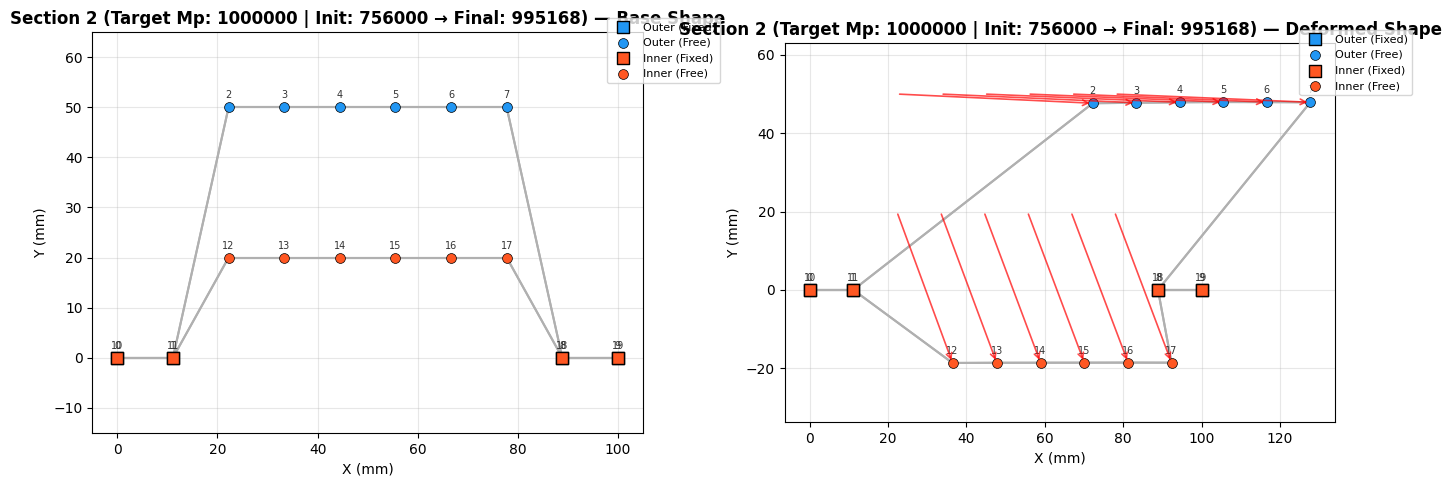

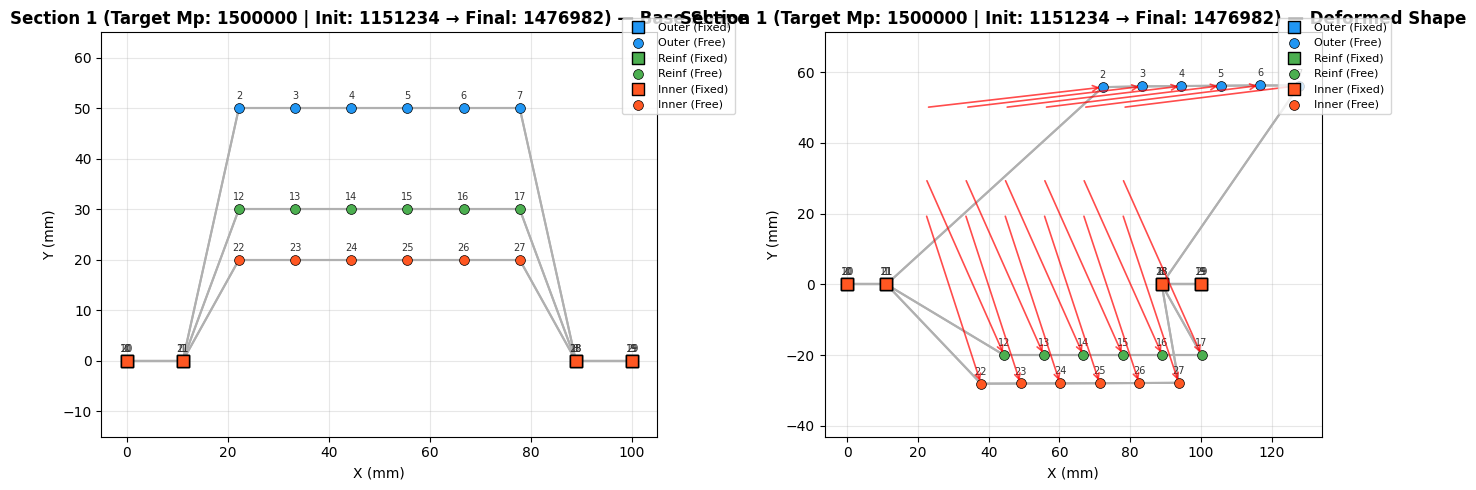

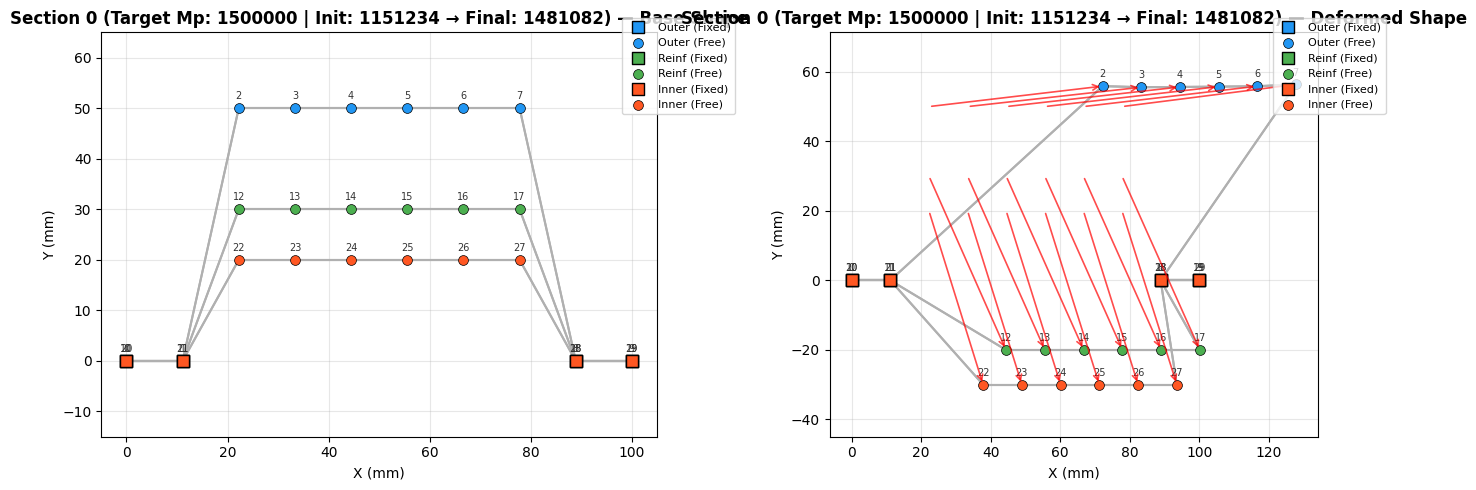


Generating 3D Visualization of Final Shape...


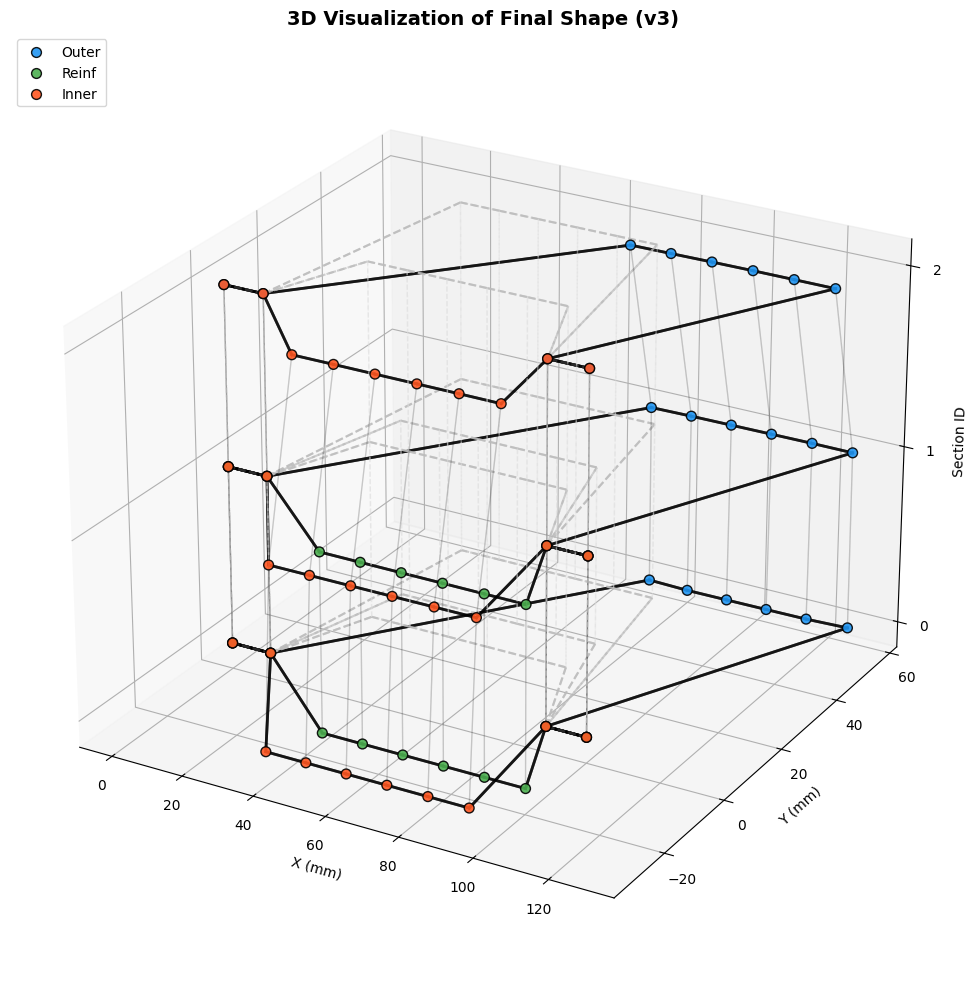

new coords: tensor([[  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 72.2222,  55.8908],
        [ 83.3333,  55.5738],
        [ 94.4444,  55.6473],
        [105.5556,  55.7399],
        [116.6667,  55.8610],
        [127.7778,  56.3682],
        [ 88.8889,   0.0000],
        [100.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 44.3659, -20.0000],
        [ 55.5761, -20.0000],
        [ 66.7335, -20.0000],
        [ 77.8941, -20.0000],
        [ 89.0549, -20.0000],
        [100.1620, -20.0000],
        [ 88.8889,   0.0000],
        [100.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 37.8010, -30.0000],
        [ 48.9635, -30.0000],
        [ 60.1103, -30.0000],
        [ 71.2628, -30.0000],
        [ 82.4201, -30.0000],
        [ 93.5573, -30.0000],
        [ 88.8889,   0.0000],
        [100.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 72.2222,  55.7335]

In [6]:

## ─────────────────────────────────────────────────────────────
## 2D Section-by-Section Visualization (v3: 열 인덱스 업데이트)
## ─────────────────────────────────────────────────────────────
def visualize_section(coords, edge_index, x_features, title="B-Pillar Cross Section",
                        deformed_coords=None, figsize=(14, 5), section_start=0):
    section_end = section_start + coords.shape[0]

    mask = (edge_index[0] >= section_start) & (edge_index[0] < section_end) & \
            (edge_index[1] >= section_start) & (edge_index[1] < section_end)
    local_edge_index = edge_index[:, mask] - section_start

    ## v3: fix_x=col2, fix_y=col3 → 어느 쪽이든 고정이면 Fixed로 표시
    fix_x    = x_features[:, 2].cpu().numpy() > 0
    fix_y    = x_features[:, 3].cpu().numpy() > 0
    is_fixed = fix_x | fix_y
    part_ids  = x_features[:, 4].cpu().numpy().astype(int)   ## v3: part_id → col 4
    coords_np = coords.cpu().detach().numpy()
    ei = local_edge_index.cpu().numpy()

    n_plots = 2 if deformed_coords is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1: axes = [axes]

    def _draw(ax, pts, subtitle):
        for i in range(ei.shape[1]):
            s, d = ei[0, i], ei[1, i]
            ax.plot([pts[s, 0], pts[d, 0]], [pts[s, 1], pts[d, 1]],
                    color='#b0b0b0', linewidth=1.5, zorder=1)

        colors_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}
        marker_map = {True: 's', False: 'o'}
        label_map  = {True: 'Fixed', False: 'Free'}
        part_name  = {0: 'Outer', 1: 'Reinf', 2: 'Inner'}

        for lid in [0, 1, 2]:
            for fix in [True, False]:
                mask_node = (part_ids == lid) & (is_fixed == fix)
                if not mask_node.any(): continue
                lbl = f'{part_name[lid]} ({label_map[fix]})'
                ax.scatter(pts[mask_node, 0], pts[mask_node, 1],
                            c=colors_map[lid], marker=marker_map[fix],
                            s=80 if fix else 50, edgecolors='k', linewidths=1.0 if fix else 0.5,
                            zorder=3, label=lbl)

        for i in range(len(pts)):
            ax.annotate(str(i), (pts[i, 0], pts[i, 1]),
                        fontsize=7, ha='center', va='bottom',
                        xytext=(0, 5), textcoords='offset points', color='#333333')

        ax.set_title(subtitle, fontsize=12, fontweight='bold')
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        y_min, y_max = pts[:, 1].min(), pts[:, 1].max()
        ax.set_ylim(y_min - 15, y_max + 15)
        ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.15, 1.05))

    _draw(axes[0], coords_np, f'{title} — Base Shape')

    if deformed_coords is not None:
        def_np = deformed_coords.cpu().detach().numpy()
        _draw(axes[1], def_np, f'{title} — Deformed Shape')
        for i in range(len(coords_np)):
            dx = def_np[i, 0] - coords_np[i, 0]
            dy = def_np[i, 1] - coords_np[i, 1]
            if np.sqrt(dx**2 + dy**2) > 1e-3:
                axes[1].annotate('',
                    xy=(def_np[i, 0], def_np[i, 1]),
                    xytext=(coords_np[i, 0], coords_np[i, 1]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2, alpha=0.7))

    plt.tight_layout()
    plt.show()

## ── 시각화 실행부 ──
## v3: section_offsets=[0,30,60], num_nodes_in_section=[30,30,20]
num_nodes_in_section = [30, 30, 20]
section_offsets      = [0, 30, 60]

print("\n" + "="*70)
print("Generating 2D Section Cross-sections...")
print("="*70)

for i in (2, 1, 0):
    s = section_offsets[i]
    e = s + num_nodes_in_section[i]

    base_coords      = data.x[s:e, :2]
    deformed         = info['new_coords'][s:e]
    section_features = data.x[s:e, :]

    target_mp_val  = target_mps[i]
    ## v3: t=col6:7, fy=col7:8
    initial_mp_val = calculate_mpl(base_coords,
                                    section_features[:, 6:7],
                                    section_features[:, 7:8], None).item()
    final_mp_val   = info['pred_mp'][i]

    title_str = (f'Section {i} '
                 f'(Target Mp: {target_mp_val:.0f} | '
                 f'Init: {initial_mp_val:.0f} → Final: {final_mp_val:.0f})')

    visualize_section(
        coords=base_coords,
        edge_index=data.edge_index,
        x_features=section_features,
        title=title_str,
        deformed_coords=deformed,
        section_start=s,
    )

## ─────────────────────────────────────────────────────────────
## 3D Visualization (v3: 열 인덱스 업데이트)
## ─────────────────────────────────────────────────────────────
def visualize_3d_final_shape(base_coords, new_coords, edge_index, part_ids, section_ids, edge_attr):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    base_np      = base_coords.cpu().numpy()
    deformed_np  = new_coords.cpu().detach().numpy()
    edge_np      = edge_index.cpu().numpy()
    part_np      = part_ids.cpu().numpy()
    section_np   = section_ids.cpu().numpy()
    edge_attr_np = edge_attr.cpu().numpy()

    color_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}

    for i in range(edge_np.shape[1]):
        u, v = edge_np[:, i]
        xs_base = [base_np[u, 0], base_np[v, 0]]
        ys_base = [base_np[u, 1], base_np[v, 1]]
        zs_base = [section_np[u], section_np[v]]
        xs_def  = [deformed_np[u, 0], deformed_np[v, 0]]
        ys_def  = [deformed_np[u, 1], deformed_np[v, 1]]
        zs_def  = [section_np[u], section_np[v]]
        edge_type = edge_attr_np[i, 3]
        if edge_type == 0.0:
            ax.plot(xs_base, ys_base, zs_base, color='#BBBBBB', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.plot(xs_def,  ys_def,  zs_def,  color='k',       linestyle='-',  linewidth=2.0, alpha=0.7)
        elif edge_type == 1.0:
            ax.plot(xs_base, ys_base, zs_base, color='#DDDDDD', linestyle='--', linewidth=1.0, alpha=0.4)
            ax.plot(xs_def,  ys_def,  zs_def,  color='k',       linestyle='-',  linewidth=1.0, alpha=0.1)

    for part_id in [0, 1, 2]:
        mask = (part_np == part_id)
        ax.scatter(deformed_np[mask, 0], deformed_np[mask, 1], section_np[mask],
                   c=color_map[part_id], label={0: 'Outer', 1: 'Reinf', 2: 'Inner'}[part_id],
                   s=50, edgecolors='k', alpha=0.9)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Section ID')
    ax.set_title('3D Visualization of Final Shape (v3)', fontsize=14, fontweight='bold')
    ax.set_zticks([0, 1, 2])
    ax.view_init(elev=25, azim=-60)
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()


print("\n" + "="*70)
print("Generating 3D Visualization of Final Shape...")
print("="*70)

visualize_3d_final_shape(
    base_coords=data.x[:, :2],
    new_coords=info['new_coords'],
    edge_index=data.edge_index,
    part_ids=data.x[:, 4],        ## v3: part_id → col 4
    section_ids=data.x[:, 5],     ## v3: section_id → col 5
    edge_attr=data.edge_attr,
)

print("new coords:", info['new_coords'])
